In [1]:
!pip install fastf1
import fastf1
import os
import pandas as pd
import numpy as np

cache_path = r'C:\Users\elesn\Downloads\Szakdoga\cache'
os.makedirs(cache_path, exist_ok=True)

fastf1.Cache.enable_cache(cache_path)


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
years = range(2018, 2024)
all_data = []

for year in years:
    session = fastf1.get_session(year, 'Bahrain', 'R')
    session.load()

    laps = session.laps.copy()
    weather = session.weather_data.copy()

    laps = pd.merge_asof(laps.sort_values('Time'),weather.sort_values('Time'),on='Time',direction='backward') #idő szerint illesztjük össze a két adattáblát
    #minden körhöz tartozni fog a hozzá időben legközelebb álló időjárási adat

    laps['Year'] = year

    all_data.append(laps)

#df = pd.concat(all_data)
#df = df[df['Driver'] == 'VER'].copy() #itt konkrétan egy pilótát választok ki, a későbbiekben ezt fogom megvizsgálni több versenyzőre
#print(df.columns)
#df.head()
df = pd.concat(all_data, ignore_index=True)

# csak a 2023-as szezon kiértékelésre
#df_2023 = df_all[df_all['Year'] == 2023].copy()

print(df.columns)
df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
core        WARNING 	Car telemetry data is unavailable!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
core        WARNING 	Car position data is unavailable!
core        WARNING 	Failed to determine `Session.t0_date`!
logger      WARNING 	Failed to load telemetry data!
req    

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity', 'Pressure',
       'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'Year'],
      dtype='object')


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FastF1Generated,IsAccurate,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,Year
0,0 days 00:09:12.347000,VET,5,0 days 00:01:35.238000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:40.676000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
1,0 days 00:09:13.814000,BOT,77,0 days 00:01:36.705000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.160000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
2,0 days 00:09:14.770000,RAI,7,0 days 00:01:37.661000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.537000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
3,0 days 00:09:15.824000,RIC,3,0 days 00:01:38.684000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.585000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
4,0 days 00:09:17.432000,GAS,10,0 days 00:01:40.323000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:42.641000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018


In [5]:
#paraméterek:
MU_0 = 85
PIT_LOSS = 21
g = 0.03

# üzemanyag fogyasztás
c_t = {
    1: 1.92,   # soft
    2: 1.87,   # medium
    3: 1.83    # hard
}

# gumikopás
d_t = {
    1: 1/25,
    2: 1/40,
    3: 1/65
}

# gumikeverékekek teljesítményvesztesége (s/lap)
alpha_t = {
    1: 0.0,
    2: 0.6,
    3: 0.9
}


In [6]:
from dataclasses import dataclass

@dataclass(frozen=True)
class State:

    tire: int
    wear: float
    fuel: float
    used_two_compounds: int
    lap: int

In [7]:
def mu(state, action):

    t = state.tire
    w = state.wear
    f = state.fuel

    pit_penalty = PIT_LOSS if action != 0 else 0

    lap_time = (MU_0+ alpha_t[t]+ g * w * f+ pit_penalty)

    

    return lap_time

In [8]:

def transition(state, action):

    t = state.tire
    w = state.wear
    f = state.fuel
    m = state.used_two_compounds
    lap = state.lap

    # fuel update
    fuel_next = max(
        0,
        f - c_t[t]
    )

    # no pit stop
    if action == 0:

        tire_next = t

        wear_next = min(
            1,
            w + d_t[t]
        )

        m_next = m

    # pit stop
    else:

        tire_next = action

        wear_next = 0

        if action != t:
            m_next = 1
        else:
            m_next = m

    return State(
        tire=tire_next,
        wear=wear_next,
        fuel=fuel_next,
        used_two_compounds=m_next,
        lap=lap + 1
    )

In [9]:
ACTIONS = [0, 1, 2, 3]
#dp:
from functools import lru_cache
@lru_cache(None)
def V(state):

    # race finished
    if state.lap > TOTAL_LAPS:

        # FIA rule
        if state.used_two_compounds == 0:
            return 1e6

        return 0

    best_value = float('inf')

    for action in ACTIONS:

    # stay out always allowed
        if action == 0:
            pass

    # pit stop
        else:

        # opcionális tiltás
            if action == state.tire and state.wear < 0.5:
                continue
        lap_cost = mu(state, action)

        next_state = transition(state, action)

        total_cost = lap_cost + V(next_state)

        best_value = min(
            best_value,
            total_cost
        )

    return best_value

In [10]:
initial_state = State(
    tire=2,          # medium
    wear=0.0,
    fuel=100,
    used_two_compounds=0,
    lap=1
)

def optimal_strategy(initial_state, total_laps):

    strategy = []

    state = initial_state

    while state.lap <= total_laps:

        best_action = None
        best_value = float('inf')

        for action in ACTIONS:

            # STAY OUT
            if action == 0:

                value = (
                    mu(state, action)
                    +
                    V(transition(state, action))
                )

            # PIT STOP
            else:

                # opcionális tiltás:
                # ne rakjon fel ugyanolyat túl korán
                if (
                    action == state.tire
                    and state.wear < 0.5
                ):
                    continue

                value = (
                    mu(state, action)
                    +
                    V(transition(state, action))
                )

            # LEGJOBB ACTION KIVÁLASZTÁSA
            if value < best_value:

                best_value = value
                best_action = action

        # stratégia mentése
        strategy.append(
            (state.lap, best_action)
        )

        # állapotfrissítés
        state = transition(
            state,
            best_action
        )

    return strategy

#strategy = optimal_strategy(
#    initial_state,
#    TOTAL_LAPS
#)

#print(strategy)

In [11]:
def simulate_race(initial_state, strategy):

    state = initial_state

    total_time = 0

    lap_times = []

    for lap, action in strategy:

        # aktuális köridő
        lap_time = mu(state, action)

        lap_times.append(lap_time)

        total_time += lap_time

        # következő állapot
        state = transition(state, action)

    return total_time, lap_times

In [12]:
evaluation_df = df.copy()

evaluation_df = evaluation_df[
    evaluation_df['Year'] == 2023
].copy()

drivers = sorted(evaluation_df['Driver'].unique())

results = []

for driver in drivers:

    print("\n====================")
    print("Driver:", driver)

    driver_df = evaluation_df[
        evaluation_df['Driver'] == driver
    ].copy()

    if driver_df.empty:
        continue

    # körszám driverenként
    global TOTAL_LAPS
    TOTAL_LAPS = int(driver_df['LapNumber'].max())
    V.cache_clear()

    # kezdeti állapot reset
    initial_state = State(
        tire=2,
        wear=0.0,
        fuel=100,
        used_two_compounds=0,
        lap=1
    )

    # DP stratégia
    strategy = optimal_strategy(initial_state,TOTAL_LAPS)

    # model szimuláció
    model_time, lap_times = simulate_race(
        initial_state,
        strategy
    )

    # real time 
    real_time = (driver_df['LapTime'].dt.total_seconds().sum())

    # regret
    regret = real_time - model_time

    results.append({
        "Driver": driver,
        "RealTime": real_time,
        "ModelTime": model_time,
        "Regret": regret
    })

    print("Model:", model_time)
    print("Real:", real_time)
    print("Regret:", regret)


Driver: ALB
Model: 4900.911562499999
Real: 5726.509999999999
Regret: 825.5984375000007

Driver: ALO
Model: 4900.911562499999
Real: 5675.373
Regret: 774.461437500001

Driver: BOT
Model: 4900.911562499999
Real: 5709.383000000001
Regret: 808.4714375000021

Driver: DEV
Model: 4815.911562499999
Real: 5659.259
Regret: 843.3474375000014

Driver: GAS
Model: 4900.911562499999
Real: 5710.4890000000005
Regret: 809.5774375000019

Driver: HAM
Model: 4900.911562499999
Real: 5687.713000000001
Regret: 786.8014375000021

Driver: HUL
Model: 4815.911562499999
Real: 5660.647
Regret: 844.7354375000014

Driver: LEC
Model: 3451.0638624999992
Real: 3886.118
Regret: 435.0541375000007

Driver: MAG
Model: 4815.911562499999
Real: 5653.493
Regret: 837.5814375000018

Driver: NOR
Model: 4730.911562499999
Real: 5643.3719999999985
Regret: 912.4604374999999

Driver: OCO
Model: 3536.782362499999
Real: 4219.566000000001
Regret: 682.7836375000015

Driver: PER
Model: 4900.911562499999
Real: 5648.723
Regret: 747.8114375000

In [13]:
results_df = pd.DataFrame(results)

print(results_df)

avg_regret = results_df["Regret"].mean()

print("AVG REGRET:", avg_regret)

   Driver  RealTime    ModelTime      Regret
0     ALB  5726.510  4900.911562  825.598438
1     ALO  5675.373  4900.911562  774.461438
2     BOT  5709.383  4900.911562  808.471438
3     DEV  5659.259  4815.911562  843.347438
4     GAS  5710.489  4900.911562  809.577438
5     HAM  5687.713  4900.911562  786.801438
6     HUL  5660.647  4815.911562  844.735438
7     LEC  3886.118  3451.063862  435.054138
8     MAG  5653.493  4815.911562  837.581438
9     NOR  5643.372  4730.911562  912.460437
10    OCO  4219.566  3536.782362  682.783638
11    PER  5648.723  4900.911562  747.811438
12    PIA  1342.585  1132.357213  210.227787
13    RUS  5692.609  4900.911562  791.697438
14    SAI  5684.788  4900.911562  783.876438
15    SAR  5637.872  4815.911562  821.960438
16    STR  5691.238  4900.911562  790.326438
17    TSU  5727.606  4900.911562  826.694438
18    VER  5636.736  4900.911562  735.824438
19    ZHO  5676.385  4815.911562  860.473438
AVG REGRET: 756.4882499750013


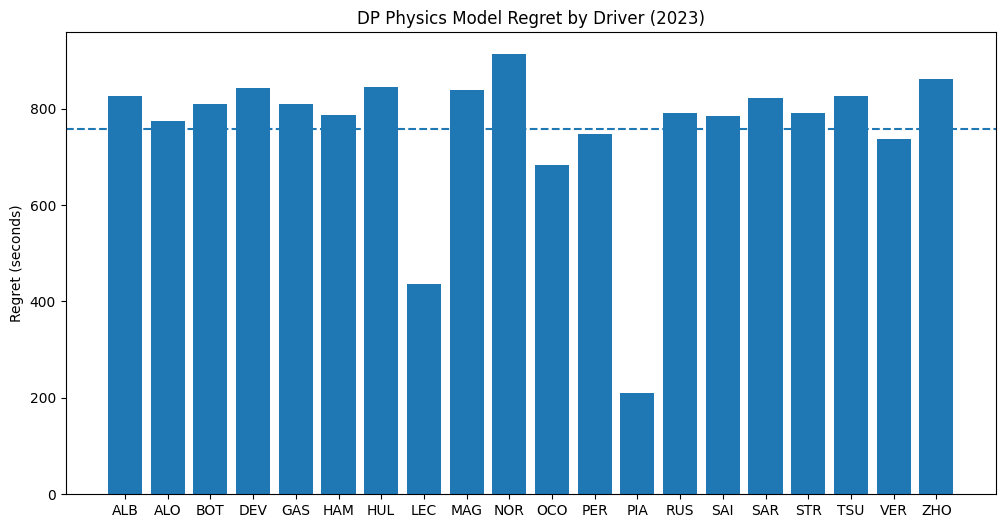

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Driver"],
    results_df["Regret"]
)

plt.axhline(avg_regret, linestyle="--")

plt.title("DP Physics Model Regret by Driver (2023)")
plt.ylabel("Regret (seconds)")

plt.show()